<a href="https://colab.research.google.com/github/Varalakshmi-skab/datasciencelearning/blob/main/Bagging_%26_Boosting_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bagging Algorithm**

*   Like **Random Forest**,we combine many models and get good accuracy..But there is still one problem.
*   The model is still making some mistakes.**Bagging** mainly combines predictions,but it does not specify focusing on correcting those mistakes.

*   so, the question is,who will correct the mistakes made by the previous model?
*   To solve this problem Boosting algorithms are introduced.

*   In Boosting each model learns from the mistakes of the previous models and tries to correct them.
*   Aa a result the overall Accuracy improves







#**Bagging Goal :**


*   Instead of trusting one model lets take opinion from many models and use voting to get better prediction

#**Boosting Goal :**


*   Lets find the mistakes made by the previous model and try to correct them






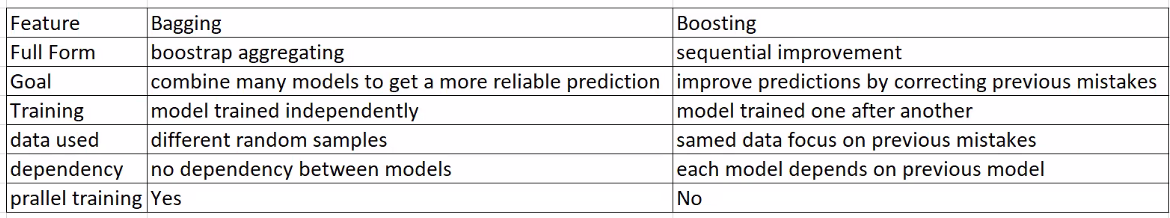

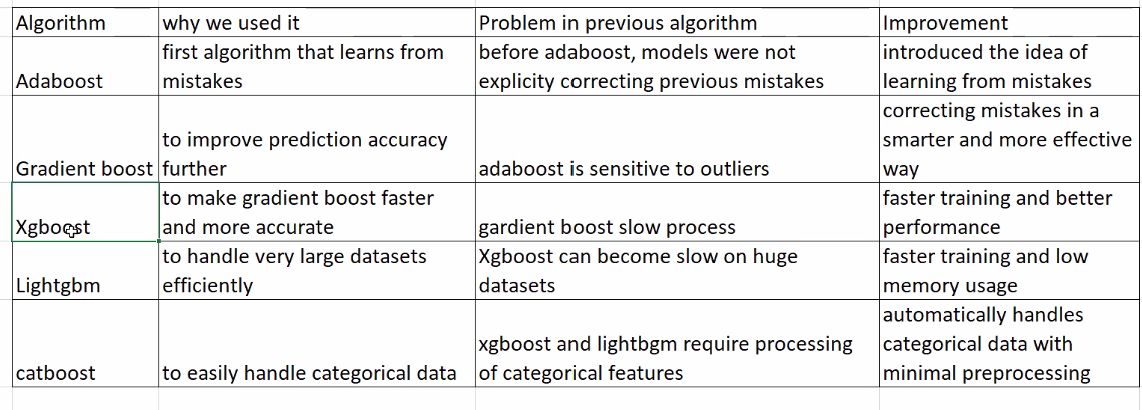

#**Using Adaboost**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
df=sns.load_dataset("titanic")

In [ ]:
df.head()

In [7]:
df.shape

(891, 15)

In [ ]:
df.isnull().sum()

In [ ]:
df.info()

In [11]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [12]:
df["age"]=df["age"].fillna(df["age"].median())
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"]=df["embark_town"].fillna(df["embark_town"].mode()[0])

In [13]:
df.drop("deck",axis=1,inplace=True)

In [14]:
df.duplicated().sum()

np.int64(116)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   sex          775 non-null    object  
 3   age          775 non-null    float64 
 4   sibsp        775 non-null    int64   
 5   parch        775 non-null    int64   
 6   fare         775 non-null    float64 
 7   embarked     775 non-null    object  
 8   class        775 non-null    category
 9   who          775 non-null    object  
 10  adult_male   775 non-null    bool    
 11  embark_town  775 non-null    object  
 12  alive        775 non-null    object  
 13  alone        775 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 75.1+ KB


In [17]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["sex"]=le.fit_transform(df["sex"])
df["embarked"]=le.fit_transform(df["embarked"])
df["class"]=le.fit_transform(df["class"])
df["who"]=le.fit_transform(df["who"])
df["embark_town"]=le.fit_transform(df["embark_town"])
df["alive"]=le.fit_transform(df["alive"])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     775 non-null    int64  
 1   pclass       775 non-null    int64  
 2   sex          775 non-null    int64  
 3   age          775 non-null    float64
 4   sibsp        775 non-null    int64  
 5   parch        775 non-null    int64  
 6   fare         775 non-null    float64
 7   embarked     775 non-null    int64  
 8   class        775 non-null    int64  
 9   who          775 non-null    int64  
 10  adult_male   775 non-null    bool   
 11  embark_town  775 non-null    int64  
 12  alive        775 non-null    int64  
 13  alone        775 non-null    bool   
dtypes: bool(2), float64(2), int64(10)
memory usage: 80.2 KB


In [19]:
df["adult_male"]=df["adult_male"].astype(int)
df["alone"]=df["alone"].astype(int)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     775 non-null    int64  
 1   pclass       775 non-null    int64  
 2   sex          775 non-null    int64  
 3   age          775 non-null    float64
 4   sibsp        775 non-null    int64  
 5   parch        775 non-null    int64  
 6   fare         775 non-null    float64
 7   embarked     775 non-null    int64  
 8   class        775 non-null    int64  
 9   who          775 non-null    int64  
 10  adult_male   775 non-null    int64  
 11  embark_town  775 non-null    int64  
 12  alive        775 non-null    int64  
 13  alone        775 non-null    int64  
dtypes: float64(2), int64(12)
memory usage: 90.8 KB


In [21]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,1,2,0,0
1,1,1,0,38.0,1,0,71.2833,0,0,2,0,0,1,0
2,1,3,0,26.0,0,0,7.9250,2,2,2,0,2,1,1
3,1,1,0,35.0,1,0,53.1000,2,0,2,0,2,1,0
4,0,3,1,35.0,0,0,8.0500,2,2,1,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,1,2,2,0,1,0,0
887,1,1,0,19.0,0,0,30.0000,2,0,2,0,2,1,1
888,0,3,0,28.0,1,2,23.4500,2,2,2,0,2,0,0
889,1,1,1,26.0,0,0,30.0000,0,0,1,1,0,1,1


In [22]:
X=df.drop("survived",axis=1)
Y=df["survived"]

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42)

In [25]:
print(X_train.shape)
print(X_test.shape)

(620, 13)
(155, 13)


In [26]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

In [28]:
model.fit(X_train,Y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [29]:
y_pred=model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(Y_test,y_pred)
print(acc)


1.0
